In [1]:
from mpi4py import MPI
from dolfinx import mesh
import numpy

In [2]:
domain = mesh.create_unit_square(MPI.COMM_WORLD, 8, 8, mesh.CellType.quadrilateral)

In [3]:
from dolfinx import fem

V = fem.functionspace(domain, ("Lagrange", 1))


uD = fem.Function(V)
uD.interpolate(lambda x: 1 + x[0] ** 2 + 2 * x[1] ** 2)

tdim = domain.topology.dim
fdim = tdim - 1
domain.topology.create_connectivity(fdim, tdim)
boundary_facets = mesh.exterior_facet_indices(domain.topology)

boundary_dofs = fem.locate_dofs_topological(V, fdim, boundary_facets)
bc = fem.dirichletbc(uD, boundary_dofs)

In [4]:
import ufl

u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

In [5]:
from dolfinx import default_scalar_type

f = fem.Constant(domain, default_scalar_type(-6))

a = ufl.dot(ufl.grad(u), ufl.grad(v)) * ufl.dx
L = f * v * ufl.dx

In [6]:
from dolfinx.fem.petsc import LinearProblem

problem = LinearProblem(
    a,
    L,
    bcs=[bc],
    petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
    petsc_options_prefix="Poisson",
)
uh = problem.solve()

In [7]:
import pyvista

print(pyvista.global_theme.jupyter_backend)

trame


In [9]:
pyvista.set_jupyter_backend("static")

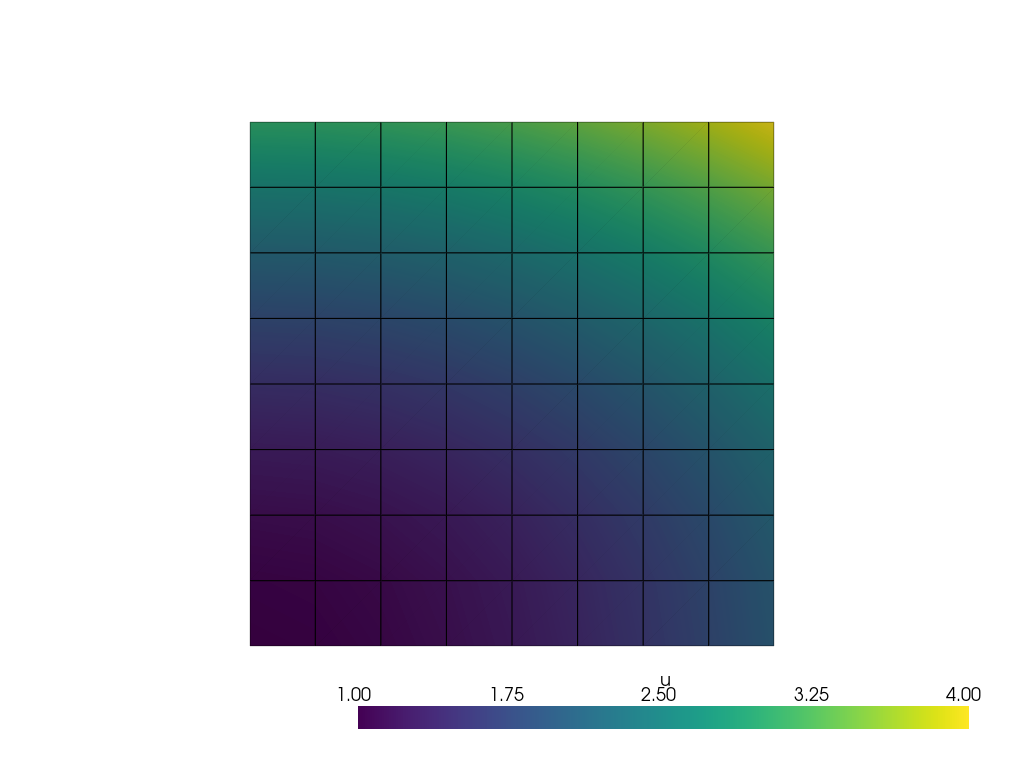

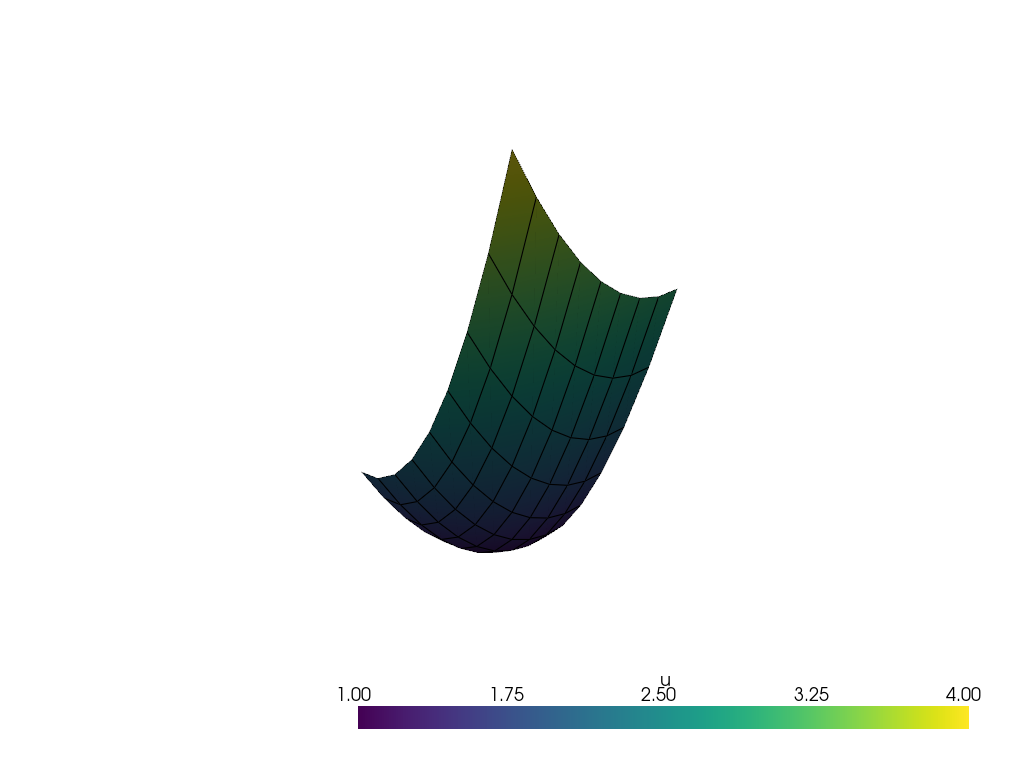

In [10]:
from dolfinx import plot

u_topology, u_cell_types, u_geometry = plot.vtk_mesh(V)

u_grid = pyvista.UnstructuredGrid(u_topology, u_cell_types, u_geometry)
u_grid.point_data["u"] = uh.x.array.real
u_grid.set_active_scalars("u")
u_plotter = pyvista.Plotter()
u_plotter.add_mesh(u_grid, show_edges=True)
u_plotter.view_xy()
if not pyvista.OFF_SCREEN:
    u_plotter.show()


warped = u_grid.warp_by_scalar()
plotter2 = pyvista.Plotter()
plotter2.add_mesh(warped, show_edges=True, show_scalar_bar=True)
if not pyvista.OFF_SCREEN:
    plotter2.show()

In [11]:
#how to export images files

from dolfinx import io
from pathlib import Path

results_folder = Path("poisson_ex_results")
results_folder.mkdir(exist_ok=True, parents=True)
filename = results_folder / "fundamentals"
with io.VTXWriter(domain.comm, filename.with_suffix(".bp"), [uh]) as vtx:
    vtx.write(0.0)
with io.XDMFFile(domain.comm, filename.with_suffix(".xdmf"), "w") as xdmf:
    xdmf.write_mesh(domain)
    xdmf.write_function(uh)